In [1]:
from analytical import *
from configuration_sampler import *
from engine import *
from trajectory import *
from electronic import *
import numpy as np
from matplotlib import pyplot as plt


In [2]:
bound_A = -0.8
bound_B = 0.8

def in_stateA(q, s):
    return q<bound_A and s == 0

def in_stateB(q, s):
    return q>bound_B and s == 0

In [ ]:
num_samples = 5000
mass = 1836.15
temp = [1263, 2105, 2526, 3158, 4210]
temp = temp[::-1]
epsilon = 0.05
Vc = 0.2 * epsilon
SHO_H = DoubleHarmonic(k=2*epsilon, x0=1.0, vc=Vc, mass=mass)
dt = 5
max_timestep = 3000
E_a = 0.8 * epsilon

ratio_lst = []
TP_ensemble_T = []

for temperature in temp:
    print('Tempearture:', temperature)
    q_inits, p_inits, S_inits = generate_mash_initial_conditions(num_samples=num_samples, mass=mass,
                                                                temp=temperature, epsilon=epsilon,
                                                                Vc=Vc)
    coeff_inits = spin_to_electronic_coefficients(S_inits)
    ensemble = []
    extracted_paths = []
    print('Initial conditions generated')

    skip_count = 0
    for q_init, p_init, coeff_init in zip(q_inits, p_inits, coeff_inits):
        E_tot = get_energy(q_init, p_init, m=mass, epsilon=epsilon, Vc=Vc)
        if E_tot < E_a:
            skip_count += 1
            continue
        v_init = p_init/mass
        S_z_check = sz_from_coeff(coeff_init)
        if S_z_check >= 0:
            raise ValueError('Sampling of incorrect electronic variables')
        act_state_init = 0
        C_init = SHO_H.eigvecs(q_init)
        initial_snapshot = Snapshot(positions=q_init,
                                    velocities=v_init,
                                    coefficients=coeff_init,
                                    active_state=act_state_init,
                                    gauge=C_init,
                                    mass=mass,
                                    is_grid=True)
        
        MASH_engine = MASHEngine(model=SHO_H,
                         dt=dt,
                         initial_snapshot=initial_snapshot)
        trajectory = MASH_engine.propagate(max_timestep)
        ensemble.append(trajectory)
    
    print('raw ensemble generated')
    
    for traj in ensemble:
        current_basin = None
        last_basin_idx = None
        for i, snap in enumerate(traj):
            q = snap.positions
            s = snap.active_state

            if in_stateA(q, s):
                if current_basin == 'B':
                    transition_path = traj[last_basin_idx : i + 1]
                    extracted_paths.append(transition_path)
                current_basin = 'A'
                last_basin_idx = i
            
            elif in_stateB(q, s):
                if current_basin == 'A':
                    transition_path = traj[last_basin_idx : i + 1]
                    extracted_paths.append(transition_path)
                current_basin = 'B'
                last_basin_idx = i
    
    if len(extracted_paths) == 0:
        print('Not a single transition path found!')
        ratio_lst.append('inf')
        continue

    total_step_in_ensemble = max_timestep * num_samples
    ratio = total_step_in_ensemble/len(extracted_paths)
    ratio_lst.append(ratio)

    TP_ensemble_T.append(extracted_paths)
    print(skip_count)
    


Tempearture: 4210
MCMC Acceptance Rate for q: 64.16%
Initial conditions generated
raw ensemble generated
4798
Tempearture: 3158
MCMC Acceptance Rate for q: 58.87%
Initial conditions generated
raw ensemble generated
4918
Tempearture: 2526
MCMC Acceptance Rate for q: 54.58%
Initial conditions generated
raw ensemble generated
4977
Tempearture: 2105
MCMC Acceptance Rate for q: 51.49%
Initial conditions generated
raw ensemble generated
4988
Tempearture: 1263
MCMC Acceptance Rate for q: 43.41%
Initial conditions generated
raw ensemble generated
Not a single transition path found!


In [5]:
print(ratio_lst)

[7751.937984496124, 17709.56316410862, 72115.38461538461, 122950.81967213115, 'inf']


In [20]:
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

# The pristine palette
winter_pine = "#22403D"
cranberry   = "#8E2B32"
golden      = "#BEA07B"
oxford_blue = "#1B3F6B"

def plot_transit_time_dist_publish(transit_times, mean_time):
    # ==========================================
    # 1. AESTHETIC SETUP (Journal Standard)
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.5,            
        "xtick.major.width": 1.5,
        "ytick.major.width": 1.5,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
    })

    # Standard single-column width (3.4 x 2.6)
    fig, ax = plt.subplots(figsize=(3.4, 2.6), dpi=400)

    # ==========================================
    # 2. PLOTTING THE DISTRIBUTION
    # ==========================================
    # The elegant, modern histogram
    ax.hist(
        transit_times,
        bins=200,
        density=True,
        color=oxford_blue,
        edgecolor='white',    # White borders separate the bins cleanly
        linewidth=0.5,
        alpha=0.5,            # Soft transparency so it doesn't overpower the KDE
        zorder=2
    )

    # The smooth KDE curve
    kde = gaussian_kde(transit_times)
    x_grid = np.linspace(min(transit_times), max(transit_times), 500)
    ax.plot(x_grid, kde(x_grid), color=oxford_blue, linewidth=2, zorder=3, label="KDE Fit")

    # The Mean Marker (Cranberry provides high contrast)
    ax.axvline(mean_time, color=golden, linestyle='--', linewidth=1.5, zorder=4,
               label=r'$\langle \tau \rangle_{brute} = 347.58$')

    # ==========================================
    # 3. LABELS & FORMATTING
    # ==========================================
    # Journal-standard unit formatting
    ax.set_xlabel(r"Transit Time $\tau$ / a.u.", fontweight='medium')
    ax.set_ylabel("Probability Density", fontweight='medium')
    ax.set_xlim([-80,2000])
    ax.set_ylim([0,0.005])

    # Grid and Ticks
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # Thicken axes
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    # Clean, borderless legend
    ax.legend(loc='upper right', frameon=False, fontsize=9)

    plt.tight_layout()
    plt.savefig("Transit_Time_Distribution.png", dpi=400, bbox_inches='tight')
    plt.show()

In [4]:
num_samples = 33000
mass = 1836.15
epsilon = 0.05
Vc = 0.2 * epsilon
SHO_H = DoubleHarmonic(k=2*epsilon, x0=1.0, vc=Vc, mass=mass)
dt = 5
max_timestep = 3000
E_a = 0.8 * epsilon

test_temp = 12000
q_inits, p_inits, S_inits = generate_mash_initial_conditions(num_samples=num_samples, mass=mass,
                                                                temp=test_temp, epsilon=epsilon,
                                                                Vc=Vc)
coeff_inits = spin_to_electronic_coefficients(S_inits)

ensemble = []
extracted_paths = []
print('Initial conditions generated')

skip_count = 0
for q_init, p_init, coeff_init in zip(q_inits, p_inits, coeff_inits):
    E_tot = get_energy(q_init, p_init, m=mass, epsilon=epsilon, Vc=Vc)
    if E_tot < E_a:
        skip_count += 1
        continue
    v_init = p_init/mass
    S_z_check = sz_from_coeff(coeff_init)
    if S_z_check >= 0:
        raise ValueError('Sampling of incorrect electronic variables')
    act_state_init = 0
    C_init = SHO_H.eigvecs(q_init)
    initial_snapshot = Snapshot(positions=q_init,
                                velocities=v_init,
                                coefficients=coeff_init,
                                active_state=act_state_init,
                                gauge=C_init,
                                mass=mass,
                                is_grid=True)
    
    MASH_engine = MASHEngine(model=SHO_H,
                        dt=dt,
                        initial_snapshot=initial_snapshot)
    trajectory = MASH_engine.propagate(max_timestep)
    ensemble.append(trajectory)

print('raw ensemble generated')
for traj in ensemble:
    current_basin = None
    last_basin_idx = None
    for i, snap in enumerate(traj):
        q = snap.positions
        s = snap.active_state

        if in_stateA(q, s):
            if current_basin == 'B':
                transition_path = traj[last_basin_idx : i + 1]
                extracted_paths.append(transition_path)
            current_basin = 'A'
            last_basin_idx = i
        
        elif in_stateB(q, s):
            if current_basin == 'A':
                transition_path = traj[last_basin_idx : i + 1]
                extracted_paths.append(transition_path)
            current_basin = 'B'
            last_basin_idx = i

total_step_in_ensemble = max_timestep * num_samples
    
if len(extracted_paths) == 0:
        print('Not a single transition path found!')
        ratio_lst.append('inf')
else:
    ratio = total_step_in_ensemble/len(extracted_paths)

print('Failure rate from sampling:', 1-skip_count/num_samples)

transition_path_ensemble = extracted_paths

transition_times = [(len(transition_path_ensemble[i])-1)*dt for i in range(len(transition_path_ensemble))]

mean_transition_time = np.mean([(len(transition_path_ensemble[i])-1)*dt for i in range(len(transition_path_ensemble))])



print(mean_transition_time)

MCMC Acceptance Rate for q: 80.20%
Initial conditions generated
raw ensemble generated
Failure rate from sampling: 0.3033636363636364
347.57613946649866


In [18]:
import pickle

brute_list = [ensemble, transition_path_ensemble, transition_times, mean_transition_time]

with open('brute.pkl', 'wb') as f:
    pickle.dump(brute_list, f)

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x107f61410>>
Traceback (most recent call last):
  File "/opt/miniconda3/envs/local_basic/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


In [19]:
import pickle

brute_list = [transition_path_ensemble, transition_times, mean_transition_time]

with open('brute_lite.pkl', 'wb') as f:
    pickle.dump(brute_list, f)

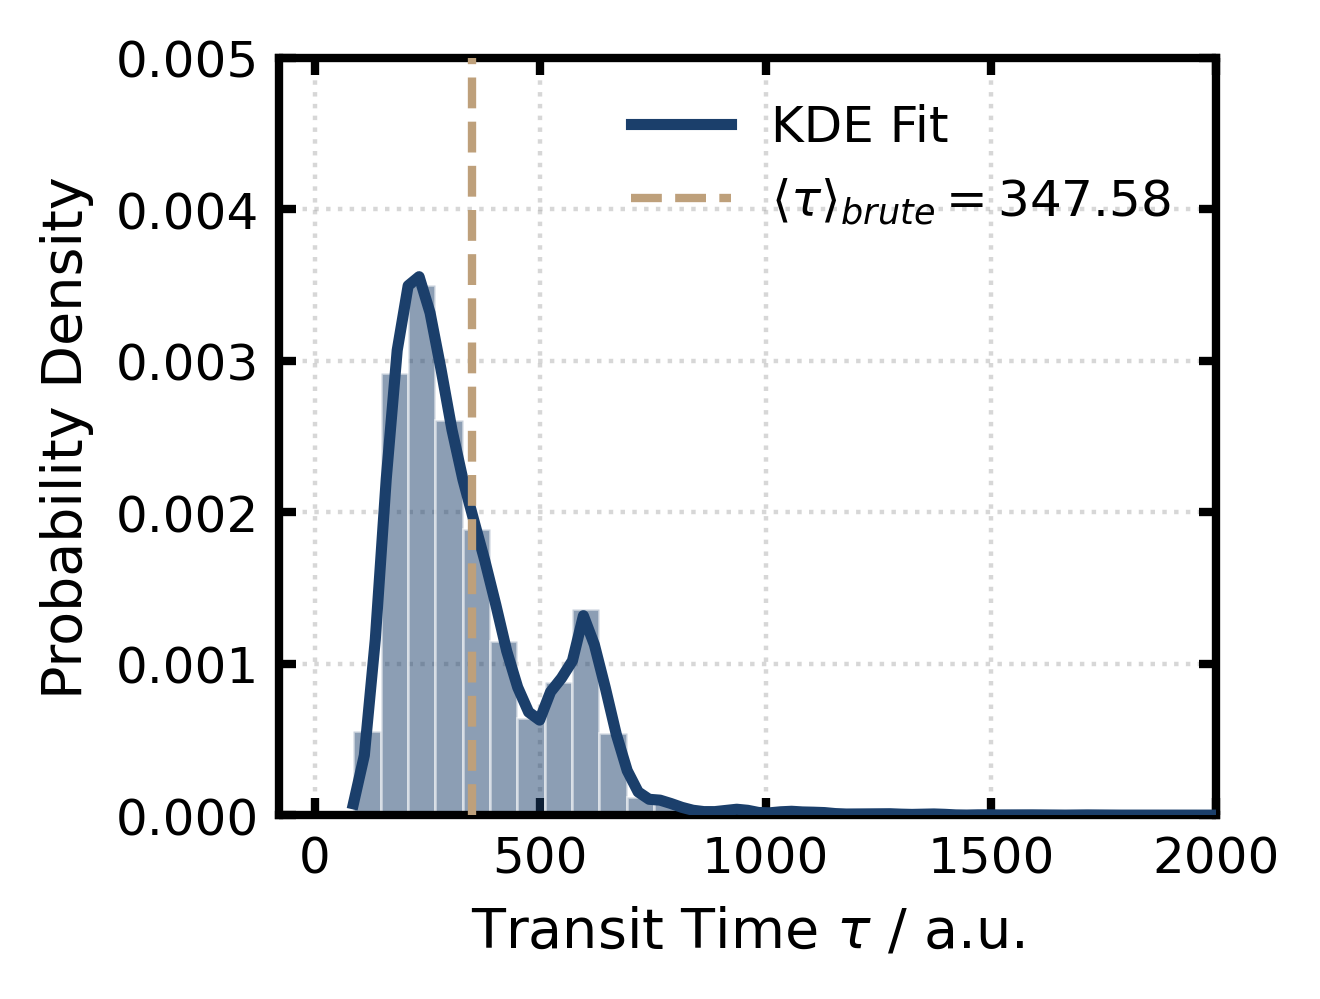

In [21]:
plot_transit_time_dist_publish(transition_times, mean_transition_time)